# **Comparing Random Forest and XGBoost Modeling Performance**

### Objectives
* Use scikit-learn to implement Random Forest and XGBoost regression models
* Compare the performances of the two models

### Introduction
We'll create and measure the relative performances of Random Forest and XGBoost regression models for predicting house prices using the California Housing Dataset. 'Performance' means both speed and accuracy.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import fetch_california_housing

In [2]:
datasets = fetch_california_housing(as_frame=True)
data = pd.concat([datasets.data, datasets.target], axis=1)

In [3]:
# About Dataset
print(datasets.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
data.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


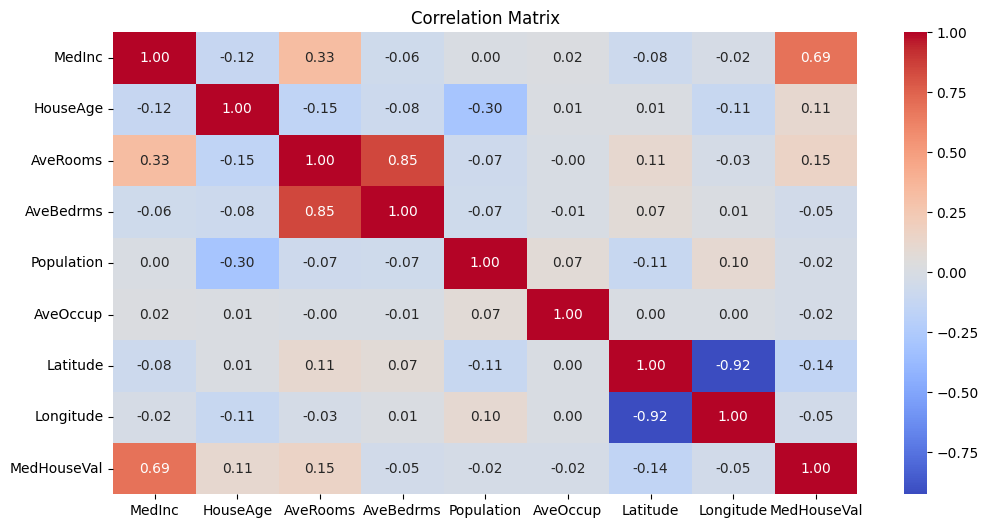

In [6]:
import seaborn as sns

# Check correlation
corr = data.corr()

plt.figure(figsize=(12,6))
sns.heatmap(data=corr, cmap='coolwarm', fmt='.2f', annot=True)
plt.title("Correlation Matrix")
plt.show()

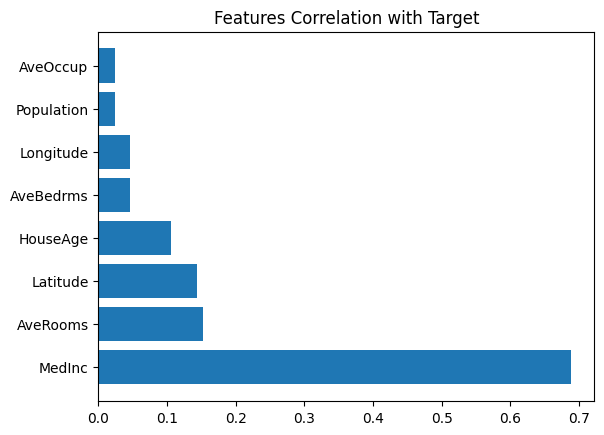

In [7]:
target_corr = corr['MedHouseVal'].abs().sort_values(ascending=False).drop('MedHouseVal')

plt.barh(target_corr.index, target_corr.values)
plt.title("Features Correlation with Target")
plt.show()

---

#### Preprocess

In [8]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = data.drop('MedHouseVal', axis=1)
y = data['MedHouseVal']

# Split the data into Train and Test subsets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Initialize Models

Define the number of base estimators, or individual trees, to be used in each model and then initialize models for Random Forest regression and XGBoost regression. We'll just use the default parameters to make the performance comparisons. As a part of the performance comparison, we'll also measure the training times for both models.

In [9]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Initialize models
n_estimators = 100
rf = RandomForestRegressor(n_estimators=n_estimators, random_state=42)
xgb = XGBRegressor(n_estimators=n_estimators, random_state=42)

In [10]:
# Fit models
# Measure training time for Random Forest
start_time_rf = time.time()
rf.fit(X_train, y_train)
end_time_rf = time.time()
rf_train_time = end_time_rf - start_time_rf

# Measure training time for XGBoost
start_time_xgb = time.time()
xgb.fit(X_train, y_train)
end_time_xgb = time.time()
xgb_train_time = end_time_xgb - start_time_xgb

In [11]:
# Prediction using models

# Measure prediction time for Random Forest
pred_stime_rf = time.time()
rf_pred = rf.predict(X_test)
pred_etime_rf = time.time()
pred_time_rf = pred_etime_rf - pred_stime_rf

# Measure prediction time for XGBoost
pred_stime_xgb = time.time()
xgb_pred = xgb.predict(X_test)
pred_etime_xgb = time.time()
pred_time_xgb = pred_etime_xgb - pred_stime_xgb

In [12]:
print(f'Random Forest:  Training Time = {rf_train_time:.3f} seconds, Testing time = {pred_time_rf:.3f} seconds')
print(f'      XGBoost:  Training Time = {xgb_train_time:.3f} seconds, Testing time = {pred_time_xgb:.3f} seconds')

Random Forest:  Training Time = 7.512 seconds, Testing time = 0.087 seconds
      XGBoost:  Training Time = 0.160 seconds, Testing time = 0.004 seconds


In [13]:
from sklearn.metrics import mean_squared_error, r2_score

mse_rf = mean_squared_error(y_test, rf_pred)
mse_xgb = mean_squared_error(y_test, xgb_pred)
r2_rf = r2_score(y_test, rf_pred)
r2_xgb = r2_score(y_test, xgb_pred)

In [14]:
print(f'Random Forest:  MSE = {mse_rf:.4f}, R^2 = {r2_rf:.4f}')
print(f'      XGBoost:  MSE = {mse_xgb:.4f}, R^2 = {r2_xgb:.4f}')


Random Forest:  MSE = 0.2557, R^2 = 0.8049
      XGBoost:  MSE = 0.2226, R^2 = 0.8301


In [ ]:
std_y = np.std(y_test)

#### Visualize

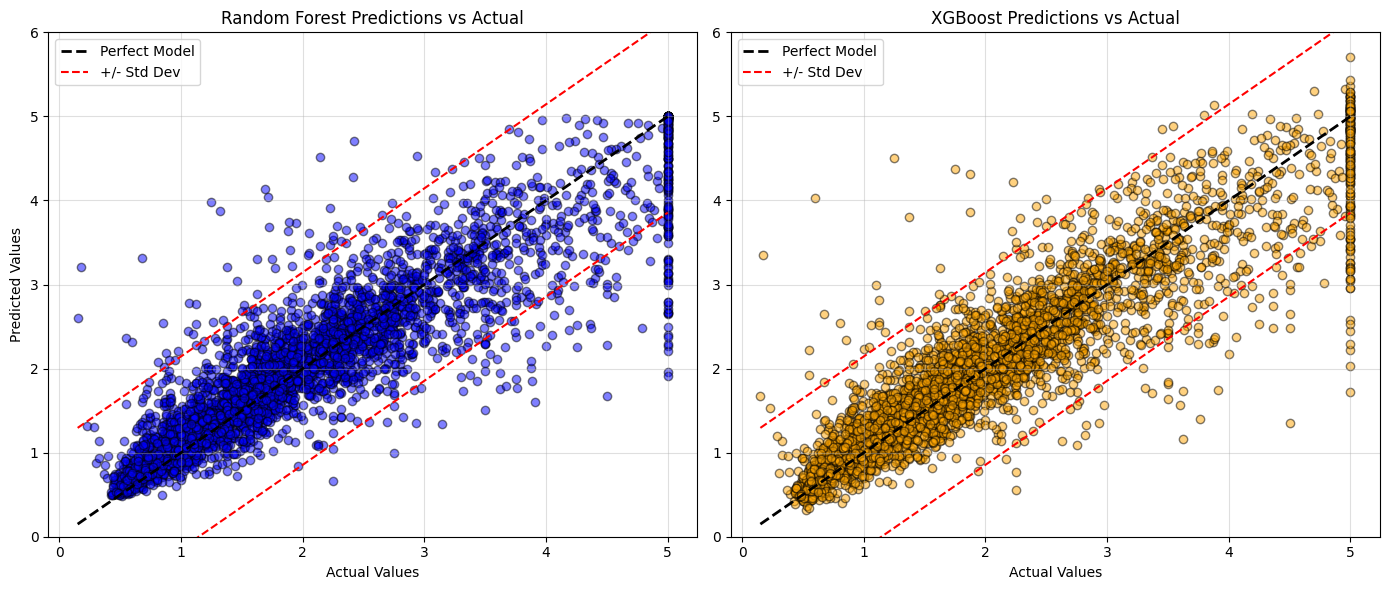

In [59]:
plt.figure(figsize=(14, 6))

# Random Forest plot
plt.subplot(1,2,1)
plt.scatter(y_test, rf_pred, alpha=0.5, color='b', ec='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label="Perfect Model")
plt.plot([y_test.min(), y_test.max()], [y_test.min() + std_y, y_test.max() + std_y], 'r--', label="+/- Std Dev")
plt.plot([y_test.min(), y_test.max()], [y_test.min() - std_y, y_test.max() - std_y], 'r--')
plt.ylim(0,6)
plt.title("Random Forest Predictions vs Actual")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.grid(True, alpha=0.4)
plt.legend()

# XGBoost plot
plt.subplot(1,2,2)
plt.scatter(y_test, xgb_pred, alpha=0.5, color='orange', ec='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label="Perfect Model")
plt.plot([y_test.min(), y_test.max()], [y_test.min() + std_y, y_test.max() + std_y], 'r--', label="+/- Std Dev")
plt.plot([y_test.min(), y_test.max()], [y_test.min() - std_y, y_test.max() - std_y], 'r--')
plt.ylim(0,6)
plt.title("XGBoost Predictions vs Actual")
plt.xlabel("Actual Values")
plt.grid(True, alpha=0.4)
plt.legend()


plt.tight_layout()
plt.show()

Both models performed very well. Most of their predictions fall within a standard deviation of the target. Interestingly, random forest "respect" the upper bound (the maximum value) present in the target by staying within its limit, while XGBoost "overshoots", or exceeds this limit.